**Generative AI Use**: For the purposes of the assignments, the use of generative AI is subject to the same policies regarding collaboration. Just as with other collaborators, each student must write down the solutions independently of the output of the interaction and the submission should include a note denoting the nature of the collaboration. The use of generative AI tools to substantially complete sections of the assignments is not in line with the spirit of the assignments, and would be a violation of the [Honor Code](https://communitystandards.stanford.edu/policies-and-guidance/honor-code).

In [3]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment1/'
FOLDERNAME = 'cs231n/assignments/assignment1/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

ModuleNotFoundError: No module named 'google.colab'

# Softmax Classifier exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

In this exercise you will:
    
- implement a fully-vectorized **loss function** for the Softmax classifier.
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [4]:
# Run some setup code for this notebook.
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# This is a bit of magic to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Some more magic so that the notebook will reload external python modules;
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

## CIFAR-10 Data Loading and Preprocessing

In [5]:
# Load the raw CIFAR-10 data.
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'

# Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# As a sanity check, we print out the size of the training and test data.
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


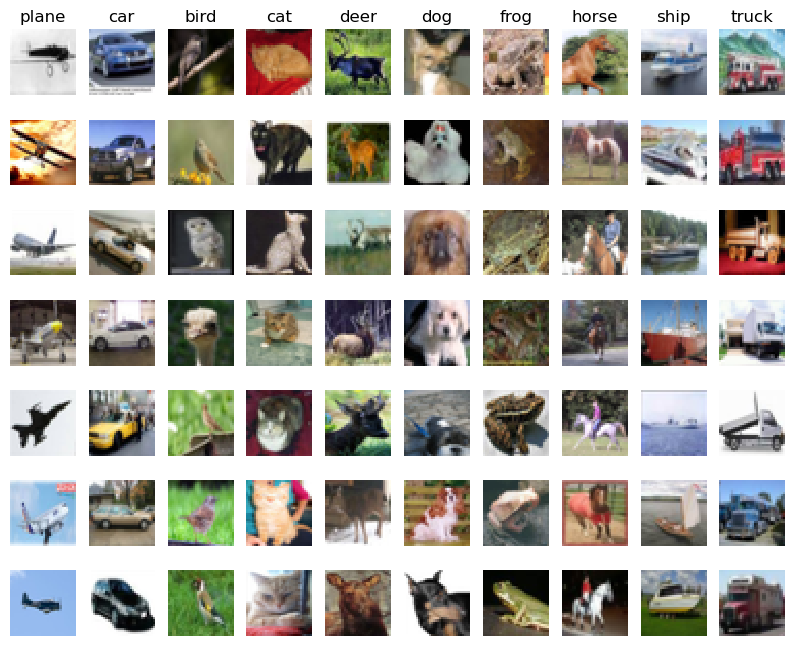

In [6]:
# Visualize some examples from the dataset.
# We show a few examples of training images from each class.
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
samples_per_class = 7
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * num_classes + y + 1
        plt.subplot(samples_per_class, num_classes, plt_idx)
        plt.imshow(X_train[idx].astype('uint8'))
        plt.axis('off')
        if i == 0:
            plt.title(cls)
plt.show()

In [7]:
# Split the data into train, val, and test sets. In addition we will
# create a small development set as a subset of the training data;
# we can use this for development so our code runs faster.
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# Our validation set will be num_validation points from the original
# training set.
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# Our training set will be the first num_train points from the original
# training set.
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# We will also make a development set, which is a small subset of
# the training set.
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# We use the first num_test points of the original test set as our
# test set.
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Validation data shape:  (1000, 32, 32, 3)
Validation labels shape:  (1000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


In [8]:
# Preprocessing: reshape the image data into rows
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# As a sanity check, print out the shapes of the data
print('Training data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Training data shape:  (49000, 3072)
Validation data shape:  (1000, 3072)
Test data shape:  (1000, 3072)
dev data shape:  (500, 3072)


[130.64189796 135.98173469 132.47391837 130.05569388 135.34804082
 131.75402041 130.96055102 136.14328571 132.47636735 131.48467347]


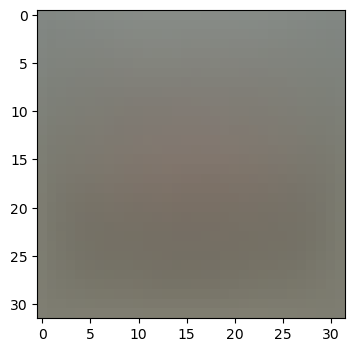

(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


In [9]:
# Preprocessing: subtract the mean image
# first: compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)
print(mean_image[:10]) # print a few of the elements
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# second: subtract the mean image from train and test data
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# third: append the bias dimension of ones (i.e. bias trick) so that our classifier
# only has to worry about optimizing a single weight matrix W.
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

## Softmax Classifier

Your code for this section will all be written inside `cs231n/classifiers/softmax.py`.

As you can see, we have prefilled the function `softmax_loss_naive` which uses for loops to evaluate the softmax loss function.

In [10]:
# Evaluate the naive implementation of the loss we provided for you:
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# generate a random Softmax classifier weight matrix of small numbers
W = np.random.randn(3073, 10) * 0.0001

loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
print('loss: %f' % (loss, ))

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.409728
loss: 2.409728
sanity check: 2.302585


**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

$\color{blue}{\textit Your Answer:}$ *因为一开始W就是随机初始化很小的数，10个类别的分数几乎相等，所以每个类别的概率约等于1/10=0.1*



The `grad` returned from the function above is right now all zero. Derive and implement the gradient for the softmax loss function and implement it inline inside the function `softmax_loss_naive`. You will find it helpful to interleave your new code inside the existing function.

To check that you have correctly implemented the gradient, you can numerically estimate the gradient of the loss function and compare the numeric estimate to the gradient that you computed. We have provided code that does this for you:

In [11]:
# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Compute the loss and its gradient at W.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should match
# almost exactly along all dimensions.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad)

# do the gradient check once again with regularization turned on
# you didn't forget the regularization gradient did you?
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad)

numerical: -3.364388 analytic: -3.364388, relative error: 7.204392e-09
numerical: 5.172990 analytic: 5.172990, relative error: 2.217547e-08
numerical: -2.820290 analytic: -2.820290, relative error: 2.069409e-08
numerical: -0.940601 analytic: -0.940601, relative error: 5.906684e-09
numerical: 3.953332 analytic: 3.953332, relative error: 2.113103e-09
numerical: -1.516587 analytic: -1.516587, relative error: 1.651731e-08
numerical: -1.166859 analytic: -1.166859, relative error: 1.727306e-08
numerical: 1.445661 analytic: 1.445661, relative error: 5.206925e-08
numerical: 0.088467 analytic: 0.088467, relative error: 4.116288e-07
numerical: -0.089850 analytic: -0.089850, relative error: 1.175605e-07
numerical: 0.798863 analytic: 0.798863, relative error: 3.302027e-08
numerical: -0.047852 analytic: -0.047852, relative error: 4.541800e-07
numerical: 2.494771 analytic: 2.494771, relative error: 1.909002e-08
numerical: 1.567042 analytic: 1.567042, relative error: 2.057520e-08
numerical: -0.278432

**Inline Question 2**

Although gradcheck is reliable softmax loss, it is possible that for SVM loss, once in a while, a dimension in the gradcheck will not match exactly. What could such a discrepancy be caused by? Is it a reason for concern? What is a simple example in one dimension where a svm loss gradient check could fail? How would change the margin affect of the frequency of this happening?

Note that SVM loss for a sample $(x_i, y_i)$ is defined as: $$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$ where $j$ iterates over all classes except the correct class $y_i$ and $s_j$ denotes the classifier score for $j^{th}$ class. $\Delta$ is a scalar margin. For more information, refer to 'Multiclass Support Vector Machine loss' on [this](https://cs231n.github.io/linear-classify/) page.

*Hint: the SVM loss function is not strictly speaking differentiable.*


$\color{blue}{\textit Your Answer:}$ *不用担心，在极少数情况发生，且是max函数本身性质导致的，不是代码写错了*  

  Δ 变大：margin 越大，越多样本会落在折点附近，出错概率越高。


In [12]:
# Next implement the function softmax_loss_vectorized; for now only compute the loss;
# we will implement the gradient in a moment.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, _ = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# The losses should match but your vectorized implementation should be much faster.
print('difference: %f' % (loss_naive - loss_vectorized))

Naive loss: 2.409728e+00 computed in 0.063266s
Vectorized loss: 2.409728e+00 computed in 0.006046s
difference: 0.000000


In [13]:
# Complete the implementation of softmax_loss_vectorized, and compute the gradient
# of the loss function in a vectorized way.

# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
tic = time.time()
_, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Naive loss and gradient: computed in %fs' % (toc - tic))

tic = time.time()
_, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('Vectorized loss and gradient: computed in %fs' % (toc - tic))

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a matrix, so
# we use the Frobenius norm to compare them.
difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('difference: %f' % difference)

Naive loss and gradient: computed in 0.067319s
Vectorized loss and gradient: computed in 0.007373s
difference: 0.000000


### Stochastic Gradient Descent

We now have vectorized and efficient expressions for the loss, the gradient and our gradient matches the numerical gradient. We are therefore ready to do SGD to minimize the loss. Your code for this part will be written inside `cs231n/classifiers/linear_classifier.py`.

In [14]:
# In the file linear_classifier.py, implement SGD in the function
# LinearClassifier.train() and then run it with the code below.
from cs231n.classifiers import Softmax
softmax = Softmax()
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

iteration 0 / 1500: loss 778.444325
iteration 100 / 1500: loss 285.579272
iteration 200 / 1500: loss 105.880313
iteration 300 / 1500: loss 39.982756
iteration 400 / 1500: loss 15.939999
iteration 500 / 1500: loss 7.137345
iteration 600 / 1500: loss 3.991579
iteration 700 / 1500: loss 2.800569
iteration 800 / 1500: loss 2.320594
iteration 900 / 1500: loss 2.130969
iteration 1000 / 1500: loss 2.075388
iteration 1100 / 1500: loss 2.166300
iteration 1200 / 1500: loss 2.095072
iteration 1300 / 1500: loss 2.080074
iteration 1400 / 1500: loss 2.100603
That took 5.744545s


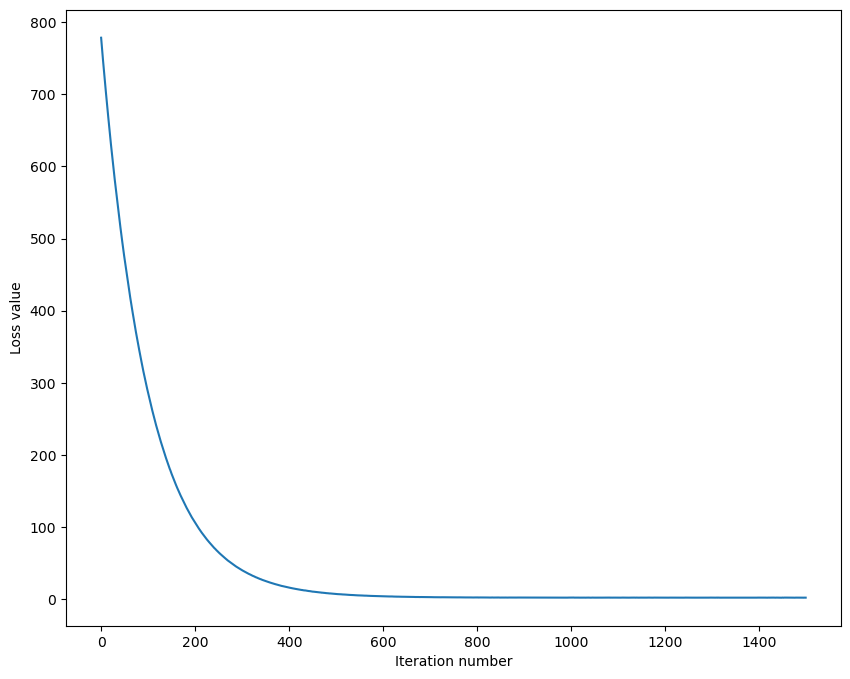

In [15]:
# A useful debugging strategy is to plot the loss as a function of
# iteration number:
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

In [16]:
# Write the LinearClassifier.predict function and evaluate the performance on
# both the training and validation set
# You should get validation accuracy of about 0.34 (> 0.33).
y_train_pred = softmax.predict(X_train)
print('training accuracy: %f' % (np.mean(y_train == y_train_pred), ))
y_val_pred = softmax.predict(X_val)
print('validation accuracy: %f' % (np.mean(y_val == y_val_pred), ))

training accuracy: 0.323367
validation accuracy: 0.340000


In [17]:
# Save the trained model for autograder.
softmax.save("softmax.npy")

softmax.npy saved.


In [40]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of about 0.365 (> 0.36) on the validation set.

# Note: you may see runtime/overflow warnings during hyper-parameter search.
# This may be caused by extreme values, and is not a bug.

# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (training_accuracy, validation_accuracy). The accuracy is simply the fraction
# of data points that are correctly classified.
results = {}
best_val = -1   # The highest validation accuracy that we have seen so far.
best_softmax = None # The Softmax object that achieved the highest validation rate.

################################################################################
# TODO:                                                                        #
# Write code that chooses the best hyperparameters by tuning on the validation #
# set. For each combination of hyperparameters, train a Softmax on the.        #
# training set, compute its accuracy on the training and validation sets, and  #
# store these numbers in the results dictionary. In addition, store the best   #
# validation accuracy in best_val and the Softmax object that achieves this.   #
# accuracy in best_softmax.                                                    #
#                                                                              #
# Hint: You should use a small value for num_iters as you develop your         #
# validation code so that the classifiers don't take much time to train; once  #
# you are confident that your validation code works, you should rerun the      #
# code with a larger value for num_iters.                                      #
################################################################################

# Provided as a reference. You may or may not want to change these hyperparameters

"""验证集图上显示，深红点位置包括这个显示出的最好的0.389
log(lr)=-6.52->lr=3e-7
log(reg)=3.7->reg=5e3


 """

# learning_rates = [1e-7, 1e-6,3e-7,5e-7]
# regularization_strengths = [2.5e4, 1e4,1e3,5e3]
 # 以 log(lr)=-6.5 为中心，窗口[-7, -6]，密集采样
learning_rates = [1e-7, 2e-7, 3e-7, 5e-7, 7e-7, 1e-6]

  # 以 log(reg)=3.7 为中心，窗口[3.2, 4.2]
regularization_strengths = [2e3, 3e3, 5e3, 7e3, 1e4]
"""分析一下这30组数据,找规律：

  - 最优组合：lr=5e-7, reg=2e3，验证准确率 0.403（突破0.4！）
  - 测试集准确率 0.383

  固定 reg=2e3，看 lr 这条线：
  lr=1e-7 → 0.305
  lr=2e-7 → 0.341
  lr=3e-7 → 0.373
  lr=5e-7 → 0.403 ← 峰值
  lr=7e-7 → 0.400 
  lr=1e-6 → 0.376
  在 lr=5e-7 附近达到峰值，往两边都下降 → 最优 lr 大概在 5e-7~7e-7之间

  固定 lr=5e-7，看 reg 这条线（结合你之前那组数据，reg=1e3时val=0.385）：
  reg=1e3 → 0.385
  reg=2e3 → 0.403 ← 峰值
  reg=3e3 → 0.400 
  reg=5e3 → 0.387
  reg=7e3 → 0.370
  同样在 reg=2e3 附近达到峰值，两边下降 → 最优 reg 大概在 1.5e3~3e3之间

  ---
  结论：峰值被夹在中间了（两边都在下降），说明这次找到的是真实的局部最优区域，不是搜索范围的边界。下一
  步在这个小区域内加密：

  learning_rates = [4e-7, 5e-7, 6e-7, 7e-7, 8e-7]
  regularization_strengths = [1.5e3, 2e3, 2.5e3, 3e3]

  这是 5×4=20 组，范围已经收得很窄了，跑完基本就能定位到很接近全局最优的点。 """

learning_rates = [4e-7, 5e-7, 6e-7, 7e-7, 8e-7]
regularization_strengths = [1.5e3, 2e3, 2.5e3, 3e3]

"""0.410，又有提升，但这次有两个值得注意的信号：

  1. 出现噪声了：固定 reg=2e3 看 lr：
  lr=4e-7 → 0.410
  lr=5e-7 → 0.392  ← 突然掉下去
  lr=6e-7 → 0.401  
  lr=7e-7 → 0.399
  不是平滑曲线了，忽高忽低。这是因为每次训练 SGD 都用随机采样的batch，加上 W 
  随机初始化，每次跑结果都会有轻微随机波动。说明现在已经进入"噪声量级"——再继续精调0.001、0.002的差距，
  可能只是随机性，不是真的更优。
  
  2. 最优点卡在边界了：
  - 最高分 lr=4e-7 正好是这次搜索范围的最小值（左边界）
  - 第二高分 lr=7e-7, reg=1.5e3 同样也是 0.410，reg=1.5e3 也是范围最小值

  这正是我之前说的边界警示——说明往更小的方向（lr<4e-7，reg<1.5e3）可能还有提升空间，没有探到头。

  ---
  建议：可以再试一组更靠左下的范围：
  learning_rates = [2e-7, 3e-7, 4e-7]
  regularization_strengths = [5e2, 1e3, 1.5e3]
  
  但说实话，从 0.403 → 0.410 这种提升已经很小，且夹杂噪声，继续调可能收益递减。0.41 验证集 / 0.387
  但是这个已经开始回退了
  这次结果很有用——证明了之前的最优点是真实的，不是边界假象。

  看新这批数据：

  reg=500  → val约 0.30~0.35  (明显更差)
  reg=1000 → val约 0.30~0.38
  reg=1500 → val约 0.36~0.40  (开始接近)

  reg 越往小（500、1000）效果反而更差，说明之前的疑虑解除了——reg=1.5e3~2e3 
  确实是真正的甜蜜点，不是因为搜索范围卡边界造成的假象，再往小完全没有提升空间。

  所以之前找到的 lr=4e-7, reg=2e3, val=0.410
  就是这一片区域里的真实最优解。粗筛也验证了方向是对的，不用再往更小的reg找了。

  可以就此收尾,这个结果（0.41验证集/0.387测试集）已经相当不错了。剩下两道 Inline
  Question（权重可视化解释 + softmax vs SVM理论题）要做吗？

  测试集已经是不错的结果（原始cs231n要求只是>0.36）。你想再试一组确认边界，还是就此收尾？"""

# learning_rates = [2e-7, 3e-7, 4e-7]
# regularization_strengths = [5e2, 1e3, 1.5e3]

"""粗筛 最后一次 看是不是局部最优

lr = 10 ** np.random.uniform(-9, -4)      # 覆盖 1e-9 到 1e-4
reg = 10 ** np.random.uniform(0, 6)        # 覆盖 1 到 1e6

  跑 15-20 次随机组合，num_iters 设小一点（比如500-800）让它跑快点，记录每次的 val_accuracy。
"""
# lr = 10 ** np.random.uniform(-9, -4)      # 覆盖 1e-9 到 1e-4
# reg = 10 ** np.random.uniform(0, 6)        # 覆盖 1 到 1e6

"""
1.创建一个新的softmax实例，训练
2.用predict()在训练集和验证集上预测
3.算出train_accuracy和val_accuracy
4.存进results[(lr,reg)]=(train_accuracy,val_accuracy)
5.如果val_accuracy比best_val更高，更新best_val和best_softmax
"""

for lr in learning_rates:
    for reg in regularization_strengths:
        softmax_model=Softmax()
        softmax_model.train(X_train,y_train,learning_rate=lr,reg=reg,num_iters=1500)
        y_train_pred=softmax_model.predict(X_train)
        train_accuracy=np.mean(y_train==y_train_pred)

        y_val_pred=softmax_model.predict(X_val)
        val_accuracy=np.mean(y_val==y_val_pred)
        
        
        results[(lr,reg)]=(train_accuracy,val_accuracy)
        if val_accuracy>best_val:
            best_val=val_accuracy
            best_softmax=softmax_model




# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))

print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 4.000000e-07 reg 1.500000e+03 train accuracy: 0.385857 val accuracy: 0.381000
lr 4.000000e-07 reg 2.000000e+03 train accuracy: 0.386878 val accuracy: 0.402000
lr 4.000000e-07 reg 2.500000e+03 train accuracy: 0.386061 val accuracy: 0.388000
lr 4.000000e-07 reg 3.000000e+03 train accuracy: 0.381714 val accuracy: 0.399000
lr 5.000000e-07 reg 1.500000e+03 train accuracy: 0.394592 val accuracy: 0.398000
lr 5.000000e-07 reg 2.000000e+03 train accuracy: 0.389816 val accuracy: 0.393000
lr 5.000000e-07 reg 2.500000e+03 train accuracy: 0.380224 val accuracy: 0.398000
lr 5.000000e-07 reg 3.000000e+03 train accuracy: 0.382755 val accuracy: 0.395000
lr 6.000000e-07 reg 1.500000e+03 train accuracy: 0.396306 val accuracy: 0.408000
lr 6.000000e-07 reg 2.000000e+03 train accuracy: 0.387776 val accuracy: 0.397000
lr 6.000000e-07 reg 2.500000e+03 train accuracy: 0.385245 val accuracy: 0.386000
lr 6.000000e-07 reg 3.000000e+03 train accuracy: 0.376592 val accuracy: 0.396000
lr 7.000000e-07 reg 1.500000

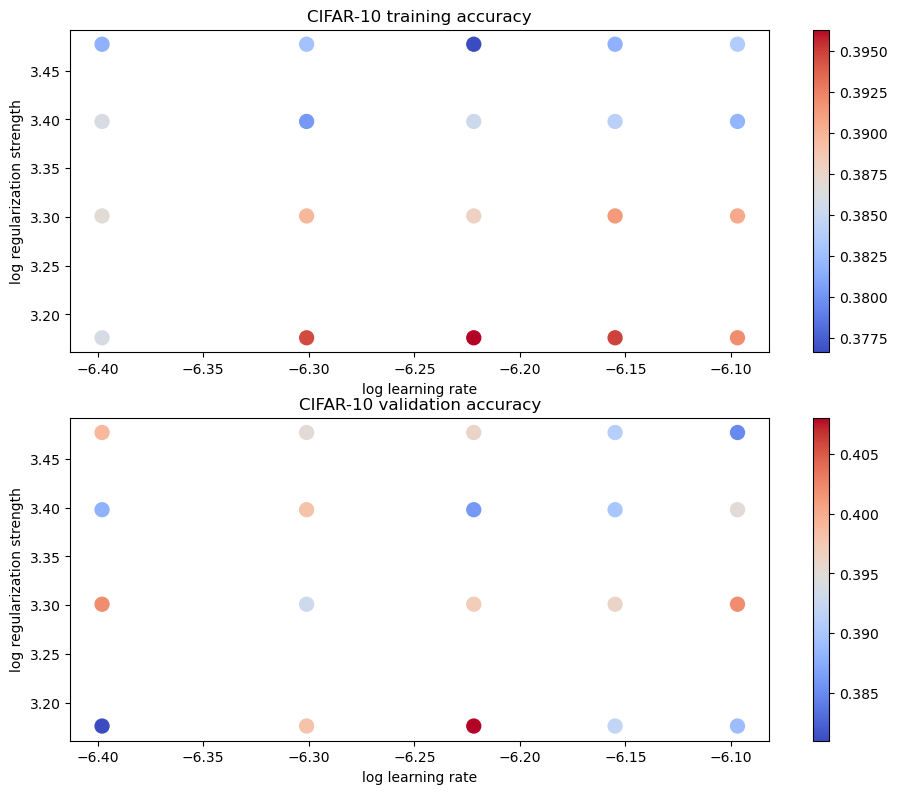

In [44]:
# Visualize the cross-validation results
import math
import pdb

# pdb.set_trace()

x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.subplot(2, 1, 1)
plt.tight_layout(pad=3)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.subplot(2, 1, 2)
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap=plt.cm.coolwarm)
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.show()

In [45]:
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax classifier on raw pixels final test set accuracy: %f' % test_accuracy)

Softmax classifier on raw pixels final test set accuracy: 0.382000


In [46]:
# Save best softmax model
best_softmax.save("best_softmax.npy")

best_softmax.npy saved.


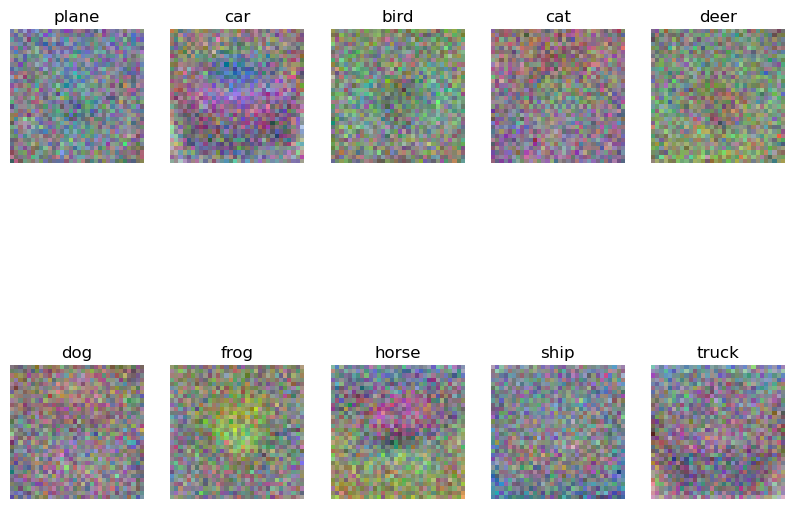

In [47]:
# Visualize the learned weights for each class.
# Depending on your choice of learning rate and regularization strength, these may
# or may not be nice to look at.
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)
w_min, w_max = np.min(w), np.max(w)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])
plt.show()

**Inline question 3**

Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.

$\color{blue}{\textit Your Answer:}$ 
观察：大部分图看起来像噪点，但是类似于car frog horse这些，中间有个模糊的色块，其他看不出
为啥：
softmax本质上是给每个类别学个模版，W的每一列就是一张理想图片，预测道时候，拿着输入图片和10个模版点积，看哪个像

问题是一个类别就一个模版，而现实中同一类别的图片差异巨大，车有正面侧面等等，模型智能吧所有的差异平均成一张模糊的图，所以绝大多数看起来想噪声，只有视觉上比较一致的类别比如马 车啥的才能看出点性状

这就是现行分类器的局限，只能学一个全局模版，没法同时表达车是很多面这种多样性，这也是学习神经网络的原因，多层网络能学到多个局部特征（边缘，纹理，形状片段），再组合起来识别物体，而不是一张模糊的平均图


**Inline Question 4** - *True or False*

Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would change the softmax loss, but leave the SVM loss unchanged.

$\color{blue}{\textit Your Answer:True}$


$\color{blue}{\textit Your Explanation:}$

  可以构造这样一个新数据点：模型对它分类非常自信且正确，即正确类别的分数远高于其他类别（超过margin
  Δ）。

  对于 SVM loss：
  $$L_i = \sum_{j\ne y_i}\max(0,\ s_j - s_{y_i} + \Delta)$$
  由于 $s_{y_i}$ 比所有 $s_j$ 高出很多（超过Δ），每一项 $s_j - s_{y_i} + \Delta < 0$，经过 max(0, ·)
  后精确变成 0。所以这个点对总SVM loss的贡献恰好是0，加入它前后SVM loss完全不变。

  对于 softmax loss：
  $$L_i = -\log(p_{y_i}) = -\log\left(\frac{e^{s_{y_i}}}{\sum_j e^{s_j}}\right)$$
  即使 $p_{y_i}$ 非常接近1（比如0.9999），也永远不会精确等于1（因为指数函数永远大于0），所以
  $-\log(p_{y_i})$ 永远是一个大于0的正数，哪怕很小。这意味着加入这个点，总softmax
  loss一定会增加一点点，不会保持不变。

  结论：SVM loss 因为有 max(0,·) 这个"截断"机制，存在精确为0的区域；而softmax
  loss的对数函数没有这种截断，永远贡献非零的值。因此存在这样的数据点——对SVM loss无影响，但会改变softmax
  loss，命题为 True。



-------------------





SVM (hinge) loss：
  $$L_i = \sum_{j\ne y_i}\max(0, s_j - s_{y_i} + \Delta)$$

  注意这里有个 max(0, ...)——如果正确类别的分数比其他类别高出 margin Δ 以上，这一项就是 精确等于0。

  Softmax loss：
  $$L_i = -\log(p_{y_i})$$

  这里没有"恰好等于0"的机制——只要分数是有限值，概率 $p_{y_i}$ 永远小于1（哪怕是0.9999999），所以
  $-\log(p_{y_i})$ 永远是个大于0的小数，不会精确为0。

  ---
  思考方向：如果你加一个新样本，这个样本被模型分类得"非常正确、margin很大"，那它对 SVM loss
  的贡献会是多少？对 softmax loss 的贡献会是多少？两者一样吗？


  